In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
import os
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from utils import data

device = torch.device('cuda')
print('GPU:', torch.cuda.get_device_name(0))

GPU: NVIDIA GeForce RTX 3090


In [ ]:
# ===== Configuration =====
mouse_id     = 3
data_path    = '../data'
frozen_path  = './checkpoints/vit_frozen'
ft_path      = './checkpoints/vit_finetune'
os.makedirs(ft_path, exist_ok=True)

import os
HF_TOKEN   = os.getenv("HF_TOKEN")                                 # <-- fill in your HuggingFace token
MODEL_NAME = 'facebook/dinov3-vits16-pretrain-lvd1689m' # must match frozen notebook

# --- Token & layer config (must match frozen notebook) ---
TOKEN_TYPE     = 'patch'   # 'patch' or 'cls'
EXTRACT_LAYERS = [3]      # None = last layer; e.g. [8,9,10,11]

# --- Fine-tuning config ---
N_BLOCKS_TO_UNFREEZE = 3     # unfreeze last N of 12 blocks + token embedding layer (ViT-S)
BATCH_SIZE   = 32            # safe for RTX 3090 + ViT-S; use 16 for ViT-B
BACKBONE_LR  = 1e-5
READOUT_LR   = 1e-3
MAX_EPOCHS   = 100
PATIENCE     = 5             # early stop patience
L2_READOUT   = 1e-4

np.random.seed(1)

In [23]:
# Load full 66×264 images WITHOUT normalization
img = data.load_images(data_path, mouse_id, file=data.img_file_name[mouse_id],
                       crop=False, normalize=False)
print('raw img shape:', img.shape)

raw image shape:  (68000, 66, 264)
img:  (68000, 66, 264) 0.0 255.0 float32
raw img shape: (68000, 66, 264)


In [24]:
# Preprocess: 66×264 → (N, 3, 32, 64), ImageNet-normalized
# Pipeline: resize 64×256 → crop left 64×128 → downsample 32×64
#           → per-image [0,1] → repeat 3ch → ImageNet normalize
from utils.vit_encoding_model import preprocess_images
img = preprocess_images(img, batch_size=2000)
print('preprocessed img shape:', img.shape)
print('  mean=%.4f  std=%.4f  range=[%.2f, %.2f]' % (img.mean(), img.std(), img.min(), img.max()))

preprocessed img shape: (68000, 3, 64, 128)
  mean=0.1492  std=1.1445  range=[-2.12, 2.64]


In [25]:
# Load neurons
fname = '%s_nat60k_%s.npz' % (data.db[mouse_id]['mname'], data.db[mouse_id]['datexp'])
spks, istim_train, istim_test, xpos, ypos, spks_rep_all = data.load_neurons(
    file_path=os.path.join(data_path, fname), mouse_id=mouse_id
)
n_stim, n_neurons = spks.shape


loading activities from ../data/FX10_nat60k_2023_05_16.npz


In [26]:
itrain, ival = data.split_train_val(istim_train, train_frac=0.9)


splitting training and validation set...
itrain:  (30559,)
ival:  (3396,)


In [27]:
spks, spks_rep_all = data.normalize_spks(spks, spks_rep_all, itrain)


normalizing neural data...
finished


In [28]:
ineur      = np.arange(0, n_neurons)
spks_train = torch.from_numpy(spks[itrain][:, ineur])
spks_val   = torch.from_numpy(spks[ival][:, ineur])

# Images: (N, 3, 32, 64) already from preprocess_images()
img_train = torch.from_numpy(img[istim_train][itrain]).to(device)
img_val   = torch.from_numpy(img[istim_train][ival]).to(device)
img_test  = torch.from_numpy(img[istim_test]).to(device)

print('img_train:', img_train.shape)
print('spks_train:', spks_train.shape)

img_train: torch.Size([30559, 3, 64, 128])
spks_train: torch.Size([30559, 4792])


In [29]:
# ===== Rebuild the model (must match frozen notebook architecture) =====
from utils.vit_encoding_model import build_vit_encoder, make_model_name

model = build_vit_encoder(
    n_neurons        = len(ineur),
    model_name       = MODEL_NAME,
    vit_input_size   = (64, 128),
    out_spatial_size = (4, 8), 
    extract_layers   = EXTRACT_LAYERS,
    use_channel_proj = False,
    proj_dim         = 64,
    freeze_backbone  = True,   # selectively unfrozen below
    poisson          = True,
    hf_token         = HF_TOKEN,
    device           = device,
)

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 6328.60it/s]

ViTCore: facebook/dinov3-vits16-pretrain-lvd1689m
  patch_size=16 embed_dim=384, register_tokens=4
  ViT input: (64, 128)  →  spatial output: 4x8
  out_channels=384, out_spatial_size=(4, 8)
  frozen=True
Readout in_shape (C, Ly, Lx): (384, 4, 8)
Total: 23,498,968 | Trainable: 1,902,424 | Frozen: 21,596,544


In [ ]:
# ===== Load the frozen-backbone checkpoint as starting point =====
frozen_filename = make_model_name(
    data.mouse_names[mouse_id], data.exp_date[mouse_id],
    MODEL_NAME, TOKEN_TYPE, EXTRACT_LAYERS,
)
frozen_ckpt = os.path.join(frozen_path, frozen_filename)

if os.path.exists(frozen_ckpt):
    model.load_state_dict(torch.load(frozen_ckpt, map_location=device))
    print('Loaded frozen checkpoint:', frozen_ckpt)
else:
    print('WARNING: frozen checkpoint not found. Run vit_frozen_mouse.ipynb first.')
    print('Fine-tuning from scratch (readout will be random).')

Loaded frozen checkpoint: ./checkpoints/vit_frozen/FX10_051623_dinov3_vits16_patch_l2.pt


In [31]:
# ===== Fine-tune: unfreeze last N transformer blocks =====
from utils.vit_encoding_model import finetune_vit

ft_filename = make_model_name(
    data.mouse_names[mouse_id], data.exp_date[mouse_id],
    MODEL_NAME, TOKEN_TYPE, EXTRACT_LAYERS,
).replace('.pt', f'_ft{N_BLOCKS_TO_UNFREEZE}blocks.pt')
ft_ckpt = os.path.join(ft_path, ft_filename)
print('Fine-tune checkpoint:', ft_ckpt)

if not os.path.exists(ft_ckpt):
    best_state = finetune_vit(
        model,
        spks_train, spks_val,
        img_train,  img_val,
        n_blocks_to_unfreeze = N_BLOCKS_TO_UNFREEZE,
        max_epochs  = MAX_EPOCHS,
        batch_size  = BATCH_SIZE,
        backbone_lr = BACKBONE_LR,
        readout_lr  = READOUT_LR,
        l2_readout  = L2_READOUT,
        clamp       = True,
        patience    = PATIENCE,
        device      = device,
    )
    torch.save(best_state, ft_ckpt)
    print('Saved fine-tuned model:', ft_ckpt)

model.load_state_dict(torch.load(ft_ckpt, map_location=device))
print('Loaded fine-tuned model:', ft_ckpt)

Fine-tune checkpoint: ./checkpoints/vit_finetune/FX10_051623_dinov3_vits16_patch_l2_ft3blocks.pt
Total stages (including embeddings): 13
Unfroze last 3/13 stages (5,324,544 backbone params trainable)
Fine-tuning | max_epochs=100, patience=5
  Backbone: 5,324,544 @ lr=1.0e-05
  Proj:     0 @ lr=5.0e-05
  Readout:  1,902,424 @ lr=1.0e-03
epoch   0 | train 0.8196 | val 0.8208 | varexp 0.0682 | lr 1.0e-05 | patience 0/5 | 17.8s
epoch   1 | train 0.8169 | val 0.8199 | varexp 0.0701 | lr 1.0e-05 | patience 0/5 | 36.5s
epoch   2 | train 0.8154 | val 0.8195 | varexp 0.0709 | lr 1.0e-05 | patience 0/5 | 55.4s
epoch   3 | train 0.8143 | val 0.8191 | varexp 0.0715 | lr 1.0e-05 | patience 0/5 | 74.1s
epoch   4 | train 0.8134 | val 0.8191 | varexp 0.0717 | lr 9.9e-06 | patience 0/5 | 92.8s
epoch   5 | train 0.8128 | val 0.8190 | varexp 0.0721 | lr 9.9e-06 | patience 0/5 | 111.5s
epoch   6 | train 0.8122 | val 0.8189 | varexp 0.0722 | lr 9.9e-06 | patience 0/5 | 129.6s
epoch   7 | train 0.8117 | val

In [32]:
# ===== Evaluate fine-tuned model =====
from utils import metrics

model.eval()
ft_pred = []
with torch.no_grad():
    for k in range(0, img_test.shape[0], 64):
        pred = model(img_test[k:k+64])
        ft_pred.append(pred.cpu().numpy())
ft_pred = np.vstack(ft_pred)

ft_fev, ft_feve = metrics.feve(spks_rep_all, ft_pred)

threshold = 0.15
valid = np.where(ft_fev > threshold)[0]
print(f'Valid neurons (FEV > {threshold}): {len(valid)} / {len(ft_fev)}')
print(f'FEVE (ViT fine-tuned {N_BLOCKS_TO_UNFREEZE} blocks): {np.mean(ft_feve[ft_fev > threshold]):.4f}')

Valid neurons (FEV > 0.15): 3040 / 4792
FEVE (ViT fine-tuned 3 blocks): 0.3575


In [33]:
# ===== Load frozen model predictions for comparison =====
# Re-build and reload frozen model
frozen_model = build_vit_encoder(
    n_neurons        = len(ineur),
    model_name       = MODEL_NAME,
    vit_input_size   = (64, 128),   # ViT internal resize (H, W), divisible by 16
    out_spatial_size = (4, 8),     # readout resolution (half of 32×64 model input)
    extract_layers   = EXTRACT_LAYERS,
    use_channel_proj = False,
    proj_dim         = 64,
    freeze_backbone  = True,
    poisson          = True,
    hf_token         = HF_TOKEN,
    device           = device,
)
if os.path.exists(frozen_ckpt):
    frozen_model.load_state_dict(torch.load(frozen_ckpt, map_location=device))
    frozen_model.eval()
    frozen_pred = []
    with torch.no_grad():
        for k in range(0, img_test.shape[0], 64):
            frozen_pred.append(frozen_model(img_test[k:k+64]).cpu().numpy())
    frozen_pred = np.vstack(frozen_pred)
    frozen_fev, frozen_feve = metrics.feve(spks_rep_all, frozen_pred)
    print(f'FEVE (ViT frozen):       {np.mean(frozen_feve[frozen_fev > threshold]):.4f}')
else:
    frozen_pred = None
    print('Frozen checkpoint not found — skipping comparison')

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 3346.46it/s]


ViTCore: facebook/dinov3-vits16-pretrain-lvd1689m
  patch_size=16 embed_dim=384, register_tokens=4
  ViT input: (64, 128)  →  spatial output: 4x8
  out_channels=384, out_spatial_size=(4, 8)
  frozen=True
Readout in_shape (C, Ly, Lx): (384, 4, 8)
Total: 23,498,968 | Trainable: 1,902,424 | Frozen: 21,596,544
FEVE (ViT frozen):       0.3010


In [34]:
# ===== (Optional) Load CNN model for three-way comparison =====
from utils import model_builder, model_trainer

cnn_weight_path = './checkpoints/fullmodel'
cnn_model, in_channels = model_builder.build_model(
    NN=len(ineur), n_layers=2, n_conv=16, n_conv_mid=320
)
cnn_model_name = model_builder.create_model_name(
    data.mouse_names[mouse_id], data.exp_date[mouse_id],
    n_layers=2, in_channels=in_channels
)
cnn_model_path = os.path.join(cnn_weight_path, cnn_model_name)

if os.path.exists(cnn_model_path):
    cnn_model.load_state_dict(torch.load(cnn_model_path, map_location='cpu'))
    cnn_model = cnn_model.to(device)
    cnn_pred  = model_trainer.test_epoch(cnn_model, img_test)
    cnn_fev, cnn_feve = metrics.feve(spks_rep_all, cnn_pred)
    print(f'FEVE (CNN):              {np.mean(cnn_feve[cnn_fev > threshold]):.4f}')
else:
    cnn_pred = None
    print('CNN checkpoint not found — skipping')

core shape:  torch.Size([1, 320, 33, 65])
input shape of readout:  (320, 33, 65)
model name:  FX10_051623_2layer_16_320_clamp_norm_depthsep_pool.pt
CNN checkpoint not found — skipping


/home/carsen/anaconda3/envs/minimodel-env/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/carsen/anaconda3/envs/minimodel-env/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


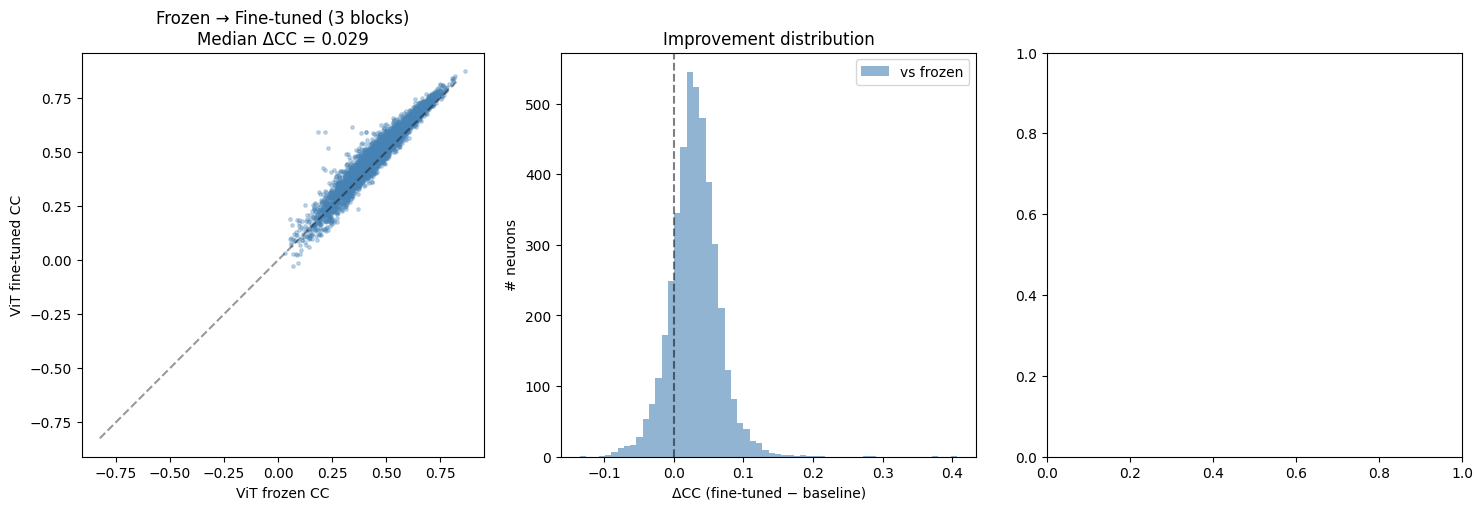

In [35]:
# ===== Plot three-way comparison =====
def cc_per_neuron(pred, target):
    return np.array([
        np.corrcoef(pred[:, i], target[:, i])[0, 1]
        for i in range(pred.shape[1])
    ])

spks_test_np = spks_rep_all.mean(1)  # mean over repeats
ft_cc = cc_per_neuron(ft_pred, spks_test_np)

n_cols = 1 + (frozen_pred is not None) + (cnn_pred is not None)
fig, axes = plt.subplots(1, n_cols + 1, figsize=(5 * (n_cols + 1), 5))
axes = list(axes)
col = 0

lim = np.nanpercentile(np.abs(ft_cc), 98) * 1.1

if frozen_pred is not None:
    frozen_cc = cc_per_neuron(frozen_pred, spks_test_np)
    ax = axes[col]; col += 1
    ax.scatter(frozen_cc, ft_cc, alpha=0.3, s=6, c='steelblue')
    ax.plot([-lim, lim], [-lim, lim], 'k--', alpha=0.4)
    ax.set_xlabel('ViT frozen CC')
    ax.set_ylabel('ViT fine-tuned CC')
    ax.set_title(f'Frozen → Fine-tuned ({N_BLOCKS_TO_UNFREEZE} blocks)\n'
                 f'Median ΔCC = {np.nanmedian(ft_cc - frozen_cc):.3f}')
    ax.set_aspect('equal')

if cnn_pred is not None:
    cnn_cc = cc_per_neuron(cnn_pred, spks_test_np)
    ax = axes[col]; col += 1
    ax.scatter(cnn_cc, ft_cc, alpha=0.3, s=6, c='coral')
    ax.plot([-lim, lim], [-lim, lim], 'k--', alpha=0.4)
    ax.set_xlabel('CNN minimodel CC')
    ax.set_ylabel('ViT fine-tuned CC')
    ax.set_title(f'CNN vs ViT fine-tuned\nMedian ΔCC = {np.nanmedian(ft_cc - cnn_cc):.3f}')
    ax.set_aspect('equal')

# Histogram of ΔCC
ax = axes[col]
if frozen_pred is not None:
    ax.hist(ft_cc - frozen_cc, bins=60, alpha=0.6, color='steelblue', label='vs frozen')
if cnn_pred is not None:
    ax.hist(ft_cc - cnn_cc,    bins=60, alpha=0.6, color='coral',     label='vs CNN')
ax.axvline(0, color='k', linestyle='--', alpha=0.5)
ax.set_xlabel('ΔCC (fine-tuned − baseline)')
ax.set_ylabel('# neurons')
ax.legend()
ax.set_title('Improvement distribution')

plt.tight_layout()
plt.savefig(os.path.join(ft_path, f'comparison_ft{N_BLOCKS_TO_UNFREEZE}blocks.png'), dpi=150)
plt.show()

In [36]:
# ===== Experiment: try different numbers of unfrozen blocks =====
# Uncomment and run this cell to sweep over different fine-tuning depths

# results = {}
# for n_blocks in [1, 2, 4, 6]:
#     m = build_vit_encoder(len(ineur), MODEL_NAME, vit_input_size=(112, 224),
#                           out_spatial_size=(33, 65), use_channel_proj=True, proj_dim=64,
#                           freeze_backbone=True, hf_token=HF_TOKEN, device=device)
#     m.load_state_dict(torch.load(frozen_ckpt, map_location=device))
#
#     ckpt_path = os.path.join(ft_path, f'{data.mouse_names[mouse_id]}_ft{n_blocks}blocks.pt')
#     if not os.path.exists(ckpt_path):
#         state = finetune_vit(m, spks_train, spks_val, img_train, img_val,
#                              n_blocks_to_unfreeze=n_blocks, n_epochs=50, batch_size=32,
#                              backbone_lr=1e-5, readout_lr=1e-3, device=device)
#         torch.save(state, ckpt_path)
#     m.load_state_dict(torch.load(ckpt_path, map_location=device))
#     m.eval()
#     pred = np.vstack([m(img_test[k:k+64]).detach().cpu().numpy()
#                       for k in range(0, img_test.shape[0], 64)])
#     fev, feve = metrics.feve(spks_rep_all, pred)
#     results[n_blocks] = np.mean(feve[fev > 0.15])
#     print(f'n_blocks={n_blocks} → FEVE={results[n_blocks]:.4f}')
#
# print('Summary:', results)